In [2]:
import simulation_2MQRM as t
import numpy as np
import qutip as qt
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
import torch
from mpmath import mpf
from mpmath import mp
import mpmath
from scipy.signal import find_peaks
import colorcet as cc
from scipy.linalg import eigh_tridiagonal
import matplotlib.ticker as mticker
from scipy.optimize import newton
from matplotlib.ticker import LogLocator, LogFormatter

In [3]:
mp.dps = 30
print(mp)

Mpmath settings:
  mp.prec = 103               [default: 53]
  mp.dps = 30                 [default: 15]
  mp.trap_complex = False     [default: False]


In [4]:
def ideal_therm_qfi(d,gap,Tlist):
    Elevels = mpf(d)
    gap = mpf(gap)
    xlist = [gap/mpf(T) for T in Tlist]
    qfi = [mpmath.power(x,4) * mpmath.exp(x) * mpmath.power(gap,-2) * (d) * mpmath.power(d+mpmath.exp(x),-2) for x in xlist]
    return qfi

def x_star_newton(d):
    g  = lambda x: (x - 4.0) - (x + 4.0) * d * np.exp(-x)
    gp = lambda x: 1.0 + d * (x + 3.0) * np.exp(-x)
    return newton(g, x0=4.0 + np.log(d), fprime=gp)

def colored_line(x, y, c, ax, **lc_kwargs):
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = LineCollection(segments, **default_kwargs)
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

In [5]:
minT, maxT, num = 1e-2,1e2,1000
Tlist = np.geomspace(minT,maxT,num)
gap = 1
dlist = [d for d in range(1,1000)]

fstarlist = []
xstarlist = []
for d in dlist:
    xstar = x_star_newton(d)
    xstarlist.append(xstar)

    fstarlist.append(ideal_therm_qfi(d,gap,[1/xstar])[0])
Tstarlist = [1/xstarlist[n] for n in range(len(xstarlist))]

In [6]:
d1,d2,d3 = 1,50,1000
ideal1 = ideal_therm_qfi(d1,gap,Tlist)
ideal2 = ideal_therm_qfi(d2,gap,Tlist)
ideal3 = ideal_therm_qfi(d3,gap,Tlist)

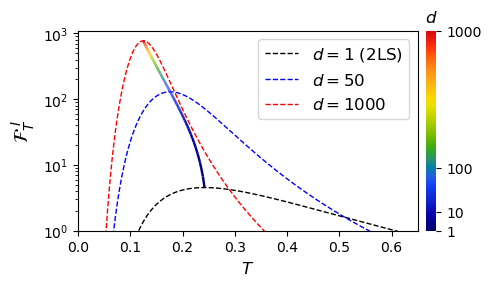

In [8]:
fig1,ax1 = plt.subplots(figsize=(4.8,2.75),layout='constrained')
ax1.set_xlim([0,0.65])
ax1.set_ylim([1,1.1e3])

twolev, = plt.semilogy(Tlist, ideal1, label=r'$d=1$ (2LS)', lw=1, ls='--',color = 'k')

halfway, = plt.semilogy(Tlist, ideal2, label=r'$d=50$', lw=1, ls='--',color = 'blue')

toppy, = plt.semilogy(Tlist, ideal3, label=r'$d=1000$', lw=1, ls='--',color = 'red')

norm = matplotlib.colors.PowerNorm(gamma=0.5,vmin=min(dlist), vmax=max(dlist), clip=False) 
cmap1 = cc.cm.rainbow4
QFI_c_line = colored_line(Tstarlist, fstarlist, c = dlist, ax=ax1, cmap = cmap1, lw=1.75, norm=norm)

ax1.set_xlabel(r'$T$', fontsize='large')
ax1.set_ylabel(r'$\mathcal{F}_T^{\ I}$', fontsize=14)


sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap1)
sm.set_array([])
cbar = fig1.colorbar(sm, ax=ax1, location='right', fraction=0.035, pad=0.025)
cbar.ax.set_title(r'$d$', pad=6)
cbar.outline.set_visible(False)
cbar.locator   = LogLocator(base=10)       # or LogLocator(base=10, subs=(1.,))
cbar.formatter = LogFormatter(base=10)
ticks = [1, 10, 100, 1000]
cbar.set_ticks(ticks)
ax1.legend(handles=[twolev, halfway, toppy],fontsize='large')
plt.savefig('appendix_ideal_qfi.png',bbox_inches="tight",dpi=1000)